In [1]:
from typing import TypedDict, Annotated

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [2]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [3]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def Chat_node(state: ChatState):
    response = llm.invoke(state["messages"])
    return {
        "messages": [response]
    }

In [5]:
checkpointer = MemorySaver()

In [6]:
graph = StateGraph(ChatState)

In [7]:
graph.add_node("Chat Node", Chat_node)

In [8]:
graph.add_edge(START, "Chat Node")
graph.add_edge("Chat Node", END)

In [9]:
Chatbot = graph.compile(
    checkpointer=checkpointer
)

In [10]:
initial_state = {
    "messages": [
        HumanMessage(content="Hello, how are you?")
    ]
}

config = {
    "configurable": {
        "thread_id": "1"
    }
}

response = Chatbot.invoke(
    initial_state,
    config=config
)

print(response["messages"][-1].content)

Hello! I'm doing great, thank you for asking. How can I help you today?


In [11]:
thread_id = "1"

while True:
    user_message = input("Type here: ")

    if user_message.strip().lower() in ["exit", "quit", "bye"]:
        print("AI: Thanks for visiting!")
        break

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    response = Chatbot.invoke(
        {
            "messages": [
                HumanMessage(content=user_message)
            ]
        },
        config=config
    )

    print("AI:", response["messages"][-1].content)

AI: Hi there! How’s your day going? Let me know if there’s anything I can help you with.
AI: Thanks for visiting!


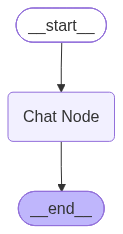

In [12]:
Chatbot

In [13]:
initial_state = {
    "messages": [
        HumanMessage(content="Hello, how are you?")
    ]
}

config = {
    "configurable": {
        "thread_id": "1"
    }
}

response = Chatbot.invoke(
    initial_state,
    config=config
)

print(response["messages"][-1].content)

I’m doing well, thanks! How about you? Anything on your mind that I can help with today?


In [14]:
thread_id = "1"

while True:
    user_message = input("Type here: ")

    if user_message.strip().lower() in ["exit", "quit", "bye"]:
        print("AI: Thanks for visiting!")
        break

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    response = Chatbot.invoke(
        {
            "messages": [
                HumanMessage(content=user_message)
            ]
        },
        config=config
    )

    print("AI:", response["messages"][-1].content)

AI: Hey there! 👋 How’s everything going? Let me know if there’s anything you’d like to chat about or need assistance with.
AI: Thanks for visiting!
